In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv("kc_house_data.csv")
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [ ]:
""" we will use
sqft_living
bedrooms
bathrooms
floors
condition
TARGET"
price """

In [9]:
X = df[[
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'condition'
]]

y = df['price']

In [11]:
#TRAINING
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
#fit trans
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
batch_model = LinearRegression()
batch_model.fit(X_train, y_train)
batch_predictions = batch_model.predict(X_test)

In [19]:
batch_mse = mean_squared_error(y_test, batch_predictions)

batch_r2 = r2_score(y_test, batch_predictions)

print("Batch Learning MSE:", batch_mse)
print("Batch Learning R2 Score:", batch_r2)

Batch Learning MSE: 72792612949.22198
Batch Learning R2 Score: 0.5184932132566569


In [25]:
#coef
print(batch_model.coef_)
#intercept
print(batch_model.intercept_)

[   304.47585251 -59597.06732842  14372.07584635  15383.25661895
  51917.87004677]
-123307.80515582743


In [28]:
X_initial = X_train_scaled[:5000]
y_initial = y_train.iloc[:5000]

X_stream = X_train_scaled[5000:]
y_stream = y_train.iloc[5000:]

In [30]:
incremental_model = SGDRegressor(
    learning_rate='constant',
    eta0=0.000001,
    max_iter=1,
    tol=None,
    random_state=42
)

In [32]:
#initial training
incremental_model.partial_fit(X_initial, y_initial)

SGDRegressor(eta0=1e-06, learning_rate='constant', max_iter=1, random_state=42,
             tol=None)

In [34]:
#now lets stream new data
batch_size = 500

for i in range(0, len(X_stream), batch_size):

    X_batch = X_stream[i:i+batch_size]
    y_batch = y_stream.iloc[i:i+batch_size]

    incremental_model.partial_fit(X_batch, y_batch)

    print(f"Updated using rows {i} to {i+batch_size}")

Updated using rows 0 to 500
Updated using rows 500 to 1000
Updated using rows 1000 to 1500
Updated using rows 1500 to 2000
Updated using rows 2000 to 2500
Updated using rows 2500 to 3000
Updated using rows 3000 to 3500
Updated using rows 3500 to 4000
Updated using rows 4000 to 4500
Updated using rows 4500 to 5000
Updated using rows 5000 to 5500
Updated using rows 5500 to 6000
Updated using rows 6000 to 6500
Updated using rows 6500 to 7000
Updated using rows 7000 to 7500
Updated using rows 7500 to 8000
Updated using rows 8000 to 8500
Updated using rows 8500 to 9000
Updated using rows 9000 to 9500
Updated using rows 9500 to 10000
Updated using rows 10000 to 10500
Updated using rows 10500 to 11000
Updated using rows 11000 to 11500
Updated using rows 11500 to 12000
Updated using rows 12000 to 12500


In [ ]:
"""
For every mini-batch:
1. Model predicts
2. Finds error
3. Adjusts weights slightly
4. Improves model --- without retraining"""

In [36]:
#final
incremental_predictions = incremental_model.predict(X_test_scaled)

In [38]:
#evaluation
incremental_mse = mean_squared_error(
    y_test,
    incremental_predictions
)

incremental_r2 = r2_score(
    y_test,
    incremental_predictions
)

print("Incremental Learning MSE:", incremental_mse)
print("Incremental Learning R2 Score:", incremental_r2)

Incremental Learning MSE: 438291867755.4134
Incremental Learning R2 Score: -1.8992022727067526


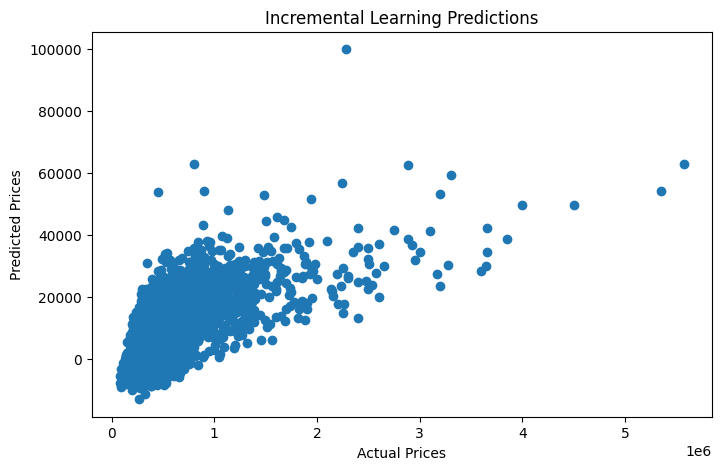

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, incremental_predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Incremental Learning Predictions")

plt.show()

In [46]:
#final comparison

print("FINAL COMPARISON")
print("\nBatch Learning R2 Score:")
print(batch_r2)

print("\nIncremental Learning R2 Score:")
print(incremental_r2)

print("\nBatch Learning MSE:")
print(batch_mse)

print("\nIncremental Learning MSE:")
print(incremental_mse)

FINAL COMPARISON

Batch Learning R2 Score:
0.5184932132566569

Incremental Learning R2 Score:
-1.8992022727067526

Batch Learning MSE:
72792612949.22198

Incremental Learning MSE:
438291867755.4134


In [52]:
df['expensive_house'] = np.where(
    df['price'] > df['price'].median(),
    1,
    0
)

In [54]:
#LOGISTIC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# features
X = df[[
    'sqft_living',
    'bedrooms',
    'bathrooms',
    'floors',
    'condition'
]]

# target
y = df['expensive_house']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# scale it
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# choose the model
model = LogisticRegression()

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7441591487393014

Confusion Matrix
[[1685  451]
 [ 655 1532]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      2136
           1       0.77      0.70      0.73      2187

    accuracy                           0.74      4323
   macro avg       0.75      0.74      0.74      4323
weighted avg       0.75      0.74      0.74      4323

